# Meal Model

## Importing Libraries

In [10]:
import pandas as pd
import numpy as np
import pickle
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

## Exploratory Data Analysis (EDA)

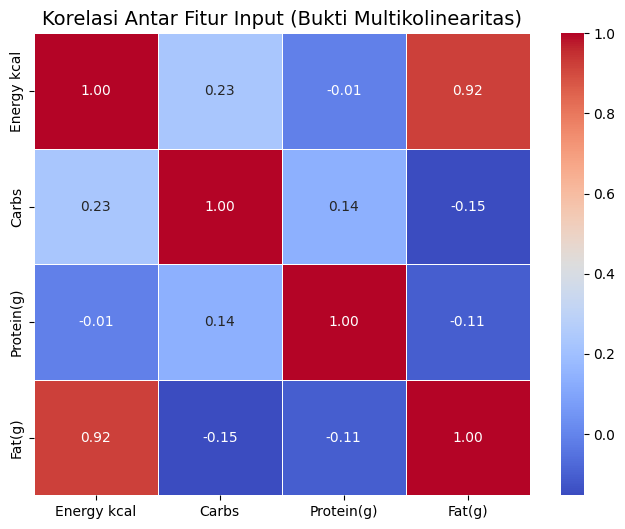

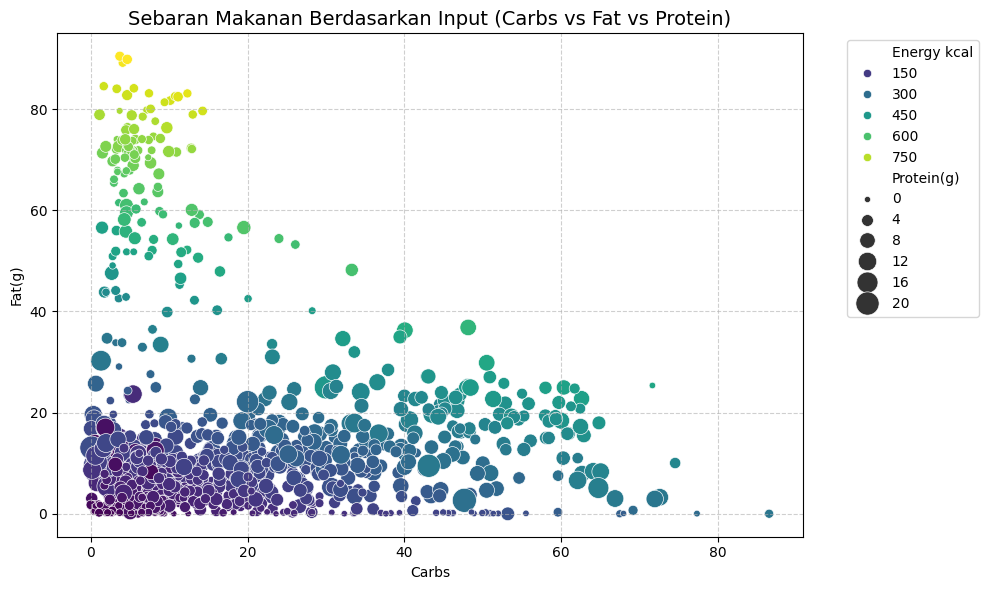

=== Ringkasan Statistik Fitur Input ===
       Energy kcal    Carbs  Protein(g)   Fat(g)
count      1028.00  1028.00     1028.00  1028.00
mean        234.40    18.54        4.78    16.24
std         186.58    16.73        3.48    20.32
min           6.61     0.00        0.00     0.00
25%         101.84     5.63        2.10     4.05
50%         176.87    12.25        4.00     9.27
75%         312.91    27.44        6.64    17.08
max         839.33    86.53       21.55    90.45

=== Ringkasan Statistik Atribut Bawaan ===
       Freesugar(g)  Fibre(g)  Cholestrol(mg)  Calcium(mg)
count       1028.00   1028.00         1028.00      1028.00
mean           8.81      1.96           25.69        59.89
std           12.32      2.76           44.74        67.21
min            0.00      0.00            0.00         0.00
25%            1.16      0.59            0.00        18.60
50%            2.83      1.33            5.41        40.80
75%           11.86      2.34           33.42        79.50
max

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Memuat Dataset langsung dari file CSV
# Ubah 'nama_file_kamu.csv' sesuai dengan nama file atau path kamu.
df = pd.read_csv('../../data/dataset_meal.csv')

# 2. Mendefinisikan Kelompok Kolom sesuai Konsep
input_features = ['Energy kcal', 'Carbs', 'Protein(g)', 'Fat(g)']
target = 'Food Items'
secondary_features = ['Freesugar(g)', 'Fibre(g)', 'Cholestrol(mg)', 'Calcium(mg)']

# --- VISUALISASI 1: Cek Multikolinearitas pada Fitur Input ---
plt.figure(figsize=(8, 6))
sns.heatmap(df[input_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korelasi Antar Fitur Input (Bukti Multikolinearitas)', fontsize=14)
plt.show()

# --- VISUALISASI 2: Sebaran Fitur Input (Melihat Klaster Makanan vs Minuman) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Carbs', y='Fat(g)', size='Protein(g)', sizes=(20, 300), hue='Energy kcal', palette='viridis')
plt.title('Sebaran Makanan Berdasarkan Input (Carbs vs Fat vs Protein)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



# --- TAMPILKAN STATISTIK DESKRIPTIF SINGKAT ---
print("=== Ringkasan Statistik Fitur Input ===")
print(df[input_features].describe().round(2))
print("\n=== Ringkasan Statistik Atribut Bawaan ===")
print(df[secondary_features].describe().round(2))

## Global Configuration

In [12]:
# Define a specific number (Seed) to ensure the code behaves exactly the same way
# every time we run it. This prevents random changes in model scores.
SEED = 26

# Lock the random number generator of NumPy using our Seed.
np.random.seed(SEED)

# Configure Pandas to display ALL columns when printing a dataframe.
# By default, Pandas hides middle columns with "..." if there are too many.
# We disable this limit so we can inspect all our features during debugging.
pd.set_option('display.max_columns', None)

## Preprocessing Data

### Load Data & Cleaning

In [13]:
# Load the raw meal data
# This file contains nutritional info (Calories, Protein, etc.) for various foods.
df_meal = pd.read_csv('../../data/dataset_meal.csv')

# Clean Column Names
# .str.strip() removes all leading/trailing spaces from column names.
df_meal.columns = df_meal.columns.str.strip()

# Verification
print(f"Data Loaded: {df_meal.shape[0]} rows, {df_meal.shape[1]} columns.")

# Remove Duplicates
# .drop_duplicates(subset=['Food Items']) keeps only the FIRST occurrence of each food
# and deletes the rest. .reset_index(drop=True) fixes the row numbers after deletion.
df_meal = df_meal.drop_duplicates(subset=['Food Items']).reset_index(drop=True)

print(f"Cleaned Data: {df_meal.shape[0]} unique food items.")

Data Loaded: 1028 rows, 9 columns.
Cleaned Data: 1028 unique food items.


In [14]:
# Rename Columns
# We rename them to simple, standard words so they are easy to type later.
# This also ensures our code doesn't break if the units in the CSV change.
df_meal = df_meal.rename(columns={
    'Energy kcal': 'Energy',  # The "Calories" column
    'Protein(g)': 'Protein',
    'Fat(g)': 'Fat',
    'Carbs': 'Carbs',
    'Fibre(g)': 'Fibre'
})

# Define Key Features for Recommendation
# When the AI searches for a "Good Meal", it will only compare these 4 columns.
features_nutrisi = ['Energy', 'Protein', 'Fat', 'Carbs']

### Splitting Dataset & Scaling

In [15]:
# Split the RAW Data (Before Scaling)
# df_meal is our raw dataframe. We split it directly.
train_df, test_df = train_test_split(
    df_meal, test_size=0.3, random_state=SEED
)

# Initialize Scaler
# We use MinMaxScaler to squash all values between 0 and 1.
# - 0 = The lowest value in the column.
# - 1 = The highest value in the column.
scaler_eval = MinMaxScaler()

# Fit Scaler ONLY on Training Data (The "Available Menu")
# The scaler learns Min/Max only from the 70% available meals.
X_train_scaled = scaler_eval.fit_transform(train_df[features_nutrisi])

# Transform Test Data (The "User Requests")
# We use the scaler from step 3. If the test data has values higher than
# what we saw in train, they will be scaled > 1.0. This is realistic behavior.
X_test_scaled = scaler_eval.transform(test_df[features_nutrisi])

## Modelling

### Model

In [16]:
# Build the model on the "Available Menu" (70% Data)
knn_eval = NearestNeighbors(n_neighbors=3, metric='euclidean')
knn_eval.fit(X_train_scaled)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


### Evaluation

In [17]:
# Simulate User Requests
# We use our trained model (knn_eval) to find the nearest neighbors for the hidden test data.
# 'X_test_scaled' represents the user's requested nutrients (scaled 0-1).
distances, indices = knn_eval.kneighbors(X_test_scaled)

# Initialize Error Trackers
# We will sum up the total differences to calculate the average error later.
total_diff_cal = 0
total_diff_prot = 0
count = len(test_df) # Total number of test cases

results = [] # List to store a few examples for display

# Evaluation Loop
for i in range(count):
    # Get the Target Meal (What the user "wanted")
    # We take the i-th row directly from the test dataframe (test_df).
    target_data = test_df.iloc[i]
    
    # Get the Recommended Meal (What the AI "found")
    # 'indices[i][0]' gives us the integer position (row number) of the best match
    # inside the TRAINING dataframe (train_df).
    posisi_di_train = indices[i][0]
    rec_data = train_df.iloc[posisi_di_train]
    
    # Calculate Deviation
    # How many calories/protein different is the recommendation from the target?
    diff_cal = abs(target_data['Energy'] - rec_data['Energy'])
    diff_prot = abs(target_data['Protein'] - rec_data['Protein'])
    
    # Add to totals
    total_diff_cal += diff_cal
    total_diff_prot += diff_prot
    
    # D. Save Top 5 Examples for Report
    if i < 5:
        results.append({
            'Target_Food': target_data['Food Items'],
            'Rec_Food': rec_data['Food Items'],
            'Target_Cal': target_data['Energy'],
            'Rec_Cal': rec_data['Energy'],
            'Diff_Cal': diff_cal
        })

# Final Statistics Calculation
avg_diff_cal = total_diff_cal / count
avg_diff_prot = total_diff_prot / count

print(f"Total Test Cases: {count}")
print(f"Average Calorie Deviation : {avg_diff_cal:.2f} kcal")
print(f"Average Protein Deviation : {avg_diff_prot:.2f} g")

print("\nExample Search Results (Top 5) ---")
print(pd.DataFrame(results)[['Target_Food', 'Rec_Food', 'Target_Cal', 'Rec_Cal', 'Diff_Cal']].to_string(index=False))

Total Test Cases: 309
Average Calorie Deviation : 10.48 kcal
Average Protein Deviation : 0.35 g

Example Search Results (Top 5) ---
                 Target_Food                                            Rec_Food  Target_Cal  Rec_Cal  Diff_Cal
               Lemon souffle                                      Orange souffle      168.51   168.28      0.23
            Schezwan chutney                                 White sauce (thick)      205.19   209.69      4.50
             Sweet corn soup                                Vegetables stir fry        32.25    30.78      1.47
                  Baked egg                                              Waffles      218.85   220.00      1.15
Banana raita (Kele ka raita) Garlic chickpea soup (Lahasun aur chane ka shoraba)       89.03    89.53      0.50


### Model Dump

In [18]:
# Scale the ENTIRE Database (100% Data)
# We must re-scale here to ensure the scaler learns the Min/Max 
# of every single food item in our inventory.
scaler_final = MinMaxScaler()
features_scaled_final = scaler_final.fit_transform(df_meal[features_nutrisi])

# Train the "Search Engine" on Scaled Data
# Now the model learns to calculate distances based on the 0-1 normalized values.
knn_final = NearestNeighbors(n_neighbors=3, metric='euclidean')
knn_final.fit(features_scaled_final) 

# Package the System
data_meal_model = {
    'knn_model': knn_final,      # The Search Engine (Trained on scaled data)
    'scaler': scaler_final,      # The Translator (We MUST save this specific scaler)
    'meal_db': df_meal,          # The Library (Raw text data for display)
    'features': features_nutrisi # The Map (Energy, Protein, Fat, Carbs)
}

# 4. Save to File
save_path = '../../models/model_meal.pickle'

with open(save_path, 'wb') as f:
    pickle.dump(data_meal_model, f)

print(f"SUCCESS: 'model_meal.pickle' saved to {save_path}")

SUCCESS: 'model_meal.pickle' saved to ../../models/model_meal.pickle
